# Synthetic ELISA Immunoassay QC Analysis

## Portfolio project by Donna Cartledge Wolf, PhD

This notebook presents a reproducible ELISA analysis workflow in Python, including data integrity checks, plate-specific 4-parameter logistic (4PL) standard curve fitting, concentration back-calculation, duplicate precision, QC recovery, plate-level QC criteria, and evaluation of position and read order effects.

> **Data safety:** All data in this project are synthetic and were generated for this portfolio. They contain no patient, client, employer, proprietary, confidential, or unpublished experimental data.

## Analytical integrity

The source CSV contains several ground truth fields used during data generation. **These fields are intentionally excluded from the analysis.** Concentrations, CVs, recoveries, and QC decisions are recalculated from the raw OD450 values.

The known synthetic design is reviewed only after the analysis is complete to see whether the workflow detected the deliberately planted anomalies.

## Analysis workflow

1. Load and verify the 25-plate dataset.

2. Retain only the fields needed for the analysis.

3. Fit an independent 4PL standard curve to each plate.

4. Back-calculate sample concentrations from OD450.

5. Apply dilution correction to unknown samples.

6. Calculate duplicate CV and QC recovery.

7. Apply illustrative plate-level QC criteria.

8. Investigate standard position bias and read order drift.

9. Classify each plate as **Pass**, **Review**, or **Fail**.

10. Compare the detected anomalies with the known synthetic design.

## Illustrative QC criteria

These criteria are simplified for this portfolio and are **not a validated regulatory SOP**:

- Mean blank OD ≤ **0.150**
- Standard curve R² ≥ **0.990**
- QC duplicate CV ≤ **20%**
- QC recovery **80% to 120%**
- Duplicate CV for quantifiable unknown samples > **20%**: review
- Illustrative assay range: **20 to 1800 pg/mL** before dilution correction
- Read order residual slope > **|0.00025 OD/read|**: review

In [261]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

LLOQ = 20.0
ULOQ = 1800.0

# Portable data loading:
# 1) relative path when notebook is in the GitHub repository,
# 2) root-level path when run from another working directory,
# 3) public GitHub raw URL when opened directly in Google Colab.
candidate_sources = [
    Path("../data/synthetic_elisa_25_plate_data.csv"),
    Path("data/synthetic_elisa_25_plate_data.csv"),
    "https://raw.githubusercontent.com/Donna-Cartledge-Wolf/elisa-immunoassay-data-analytics/main/data/synthetic_elisa_25_plate_data.csv",
]

df_source = None
for source in candidate_sources:
    try:
        if isinstance(source, Path):
            if source.exists():
                df_source = pd.read_csv(source)
                data_source_used = str(source)
                break
        else:
            df_source = pd.read_csv(source)
            data_source_used = source
            break
    except Exception:
        pass

if df_source is None:
    raise FileNotFoundError(
        "Dataset could not be loaded. If running locally, place the notebook in notebooks/ "
        "and keep the CSV in data/. If running in Colab, verify internet access."
    )

print(f"Loaded {len(df_source):,} well-level records from: {data_source_used}")


Loaded 2,400 well-level records from: https://raw.githubusercontent.com/Donna-Cartledge-Wolf/elisa-immunoassay-data-analytics/main/data/synthetic_elisa_25_plate_data.csv


In [262]:
def format_portfolio_table(df, header_map=None, formats=None):
    """
    Apply consistent presentation formatting to portfolio tables
    without changing the underlying DataFrame column names.
    """
    styled = df.style.hide(axis="index")

    if formats:
        styled = styled.format(formats)

    if header_map:
        styled = styled.format_index(
            lambda x: header_map.get(x, x),
            axis=1
        )

    return styled.set_table_styles([
        {
            "selector": "th.col_heading",
            "props": [
                ("white-space", "pre-line"),
                ("text-align", "center"),
                ("vertical-align", "middle"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("vertical-align", "middle"),
            ],
        },
        {
            "selector": "th.row_heading",
            "props": [
                ("text-align", "center"),
                ("vertical-align", "middle"),
            ],
        },
    ])

## 1. Exclude synthetic answer key fields

The raw project file includes ground truth and previously calculated columns used during data generation. Because a real assay analyst would not know those values in advance, those columns are excluded before analysis.

In [263]:
creator_only_columns = [
    "Synthetic_True_Final_Concentration_pg_mL",
    "Calculated_Assay_Concentration_pg_mL",
    "Calculated_Final_Concentration_pg_mL",
    "Result_Qualifier",
    "Replicate_CV_Pct",
    "Recovery_Pct",
    "Sample_QC_Flag",
]

analysis_columns = [
    "Plate_ID", "Batch_ID", "Run_Date", "Analyst", "Instrument_ID",
    "Read_Order", "Well", "Row", "Column",
    "Sample_ID", "Sample_Type", "Replicate", "Dilution_Factor",
    "Expected_Concentration_pg_mL", "OD450",
]

df = df_source[analysis_columns].copy()
df["Run_Date"] = pd.to_datetime(df["Run_Date"])

excluded_display_names = {
    "Synthetic_True_Final_Concentration_pg_mL":
        "Synthetic true final concentration",
    "Calculated_Assay_Concentration_pg_mL":
        "Precomputed assay concentration",
    "Calculated_Final_Concentration_pg_mL":
        "Precomputed final concentration",
    "Result_Qualifier":
        "Precomputed result qualifier",
    "Replicate_CV_Pct":
        "Precomputed replicate CV",
    "Recovery_Pct":
        "Precomputed recovery",
    "Sample_QC_Flag":
        "Precomputed sample QC flag",
}

print("Synthetic answer-key columns excluded:")
for column in creator_only_columns:
    print(" •", excluded_display_names[column])

preview_cols = [
    "Plate_ID",
    "Batch_ID",
    "Run_Date",
    "Analyst",
    "Instrument_ID",
    "Well",
    "Sample_ID",
    "Sample_Type",
    "Replicate",
    "Dilution_Factor",
    "Expected_Concentration_pg_mL",
    "OD450",
]

preview_header_map = {
    "Plate_ID": "Plate\nID",
    "Batch_ID": "Batch\nID",
    "Run_Date": "Run\nDate",
    "Analyst": "Analyst",
    "Instrument_ID": "Instrument\nID",
    "Well": "Well",
    "Sample_ID": "Sample\nID",
    "Sample_Type": "Sample\nType",
    "Replicate": "Replicate",
    "Dilution_Factor": "Dilution\nFactor",
    "Expected_Concentration_pg_mL": "Expected Conc.\n(pg/mL)",
    "OD450": "OD450",
}

preview = df[preview_cols].head(8).copy()

display(
    preview.style
    .hide(axis="index")
    .format({
        "Run_Date": lambda x: x.strftime("%Y-%m-%d"),
        "Expected_Concentration_pg_mL":
            lambda x: "" if pd.isna(x) else f"{x:.1f}",
        "OD450": "{:.5f}",
    })
    .format_index(
        lambda x: preview_header_map.get(x, x),
        axis=1
    )
    .set_table_styles([
        {
            "selector": "th.col_heading",
            "props": [
                ("white-space", "pre-line"),
                ("text-align", "center"),
                ("vertical-align", "middle"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("vertical-align", "middle"),
            ],
        },
    ])
)


Synthetic answer-key columns excluded:
 • Synthetic true final concentration
 • Precomputed assay concentration
 • Precomputed final concentration
 • Precomputed result qualifier
 • Precomputed replicate CV
 • Precomputed recovery
 • Precomputed sample QC flag


Plate ID,Batch ID,Run Date,Analyst,Instrument ID,Well,Sample ID,Sample Type,Replicate,Dilution Factor,Expected Conc. (pg/mL),OD450
PLT-001,BATCH-01,2026-01-05,Analyst_A,ELISA_Reader_01,A1,STD_2000,Standard,1,1,2000.0,2.26420
PLT-001,BATCH-01,2026-01-05,Analyst_A,ELISA_Reader_01,A2,STD_2000,Standard,2,1,2000.0,2.28227
PLT-001,BATCH-01,2026-01-05,Analyst_A,ELISA_Reader_01,A3,BLANK,Blank,1,1,0.0,0.04269
PLT-001,BATCH-01,2026-01-05,Analyst_A,ELISA_Reader_01,A4,BLANK,Blank,2,1,0.0,0.04364
PLT-001,BATCH-01,2026-01-05,Analyst_A,ELISA_Reader_01,A5,SMP-0001,Unknown,1,2,,0.26485
PLT-001,BATCH-01,2026-01-05,Analyst_A,ELISA_Reader_01,A6,SMP-0001,Unknown,2,2,,0.25765
PLT-001,BATCH-01,2026-01-05,Analyst_A,ELISA_Reader_01,A7,SMP-0002,Unknown,1,1,,0.40607
PLT-001,BATCH-01,2026-01-05,Analyst_A,ELISA_Reader_01,A8,SMP-0002,Unknown,2,1,,0.42298


## 2. Data integrity checks

In [264]:
integrity = pd.Series({
    "Total well records": len(df),
    "Unique plates": df["Plate_ID"].nunique(),
    "Minimum wells per plate": df.groupby("Plate_ID").size().min(),
    "Maximum wells per plate": df.groupby("Plate_ID").size().max(),
    "Unique analysts": df["Analyst"].nunique(),
    "Unique instruments": df["Instrument_ID"].nunique(),
    "Missing OD450 values": int(df["OD450"].isna().sum()),
})

integrity_display = (
    integrity
    .rename_axis("Integrity_Check")
    .reset_index(name="Value")
)

integrity_header_map = {
    "Integrity_Check": "Integrity\nCheck",
    "Value": "Value",
}

display(
    format_portfolio_table(
        integrity_display,
        header_map=integrity_header_map
    )
)

sample_type_counts = (
    df.groupby(["Plate_ID", "Sample_Type"])
      .size()
      .unstack(fill_value=0)
)

print("\nPer-plate sample-type counts (first five plates):")
sample_type_display = (
    sample_type_counts
    .head()
    .reset_index()
)

sample_type_header_map = {
    "Plate_ID": "Plate\nID",
    "Blank": "Blank",
    "QC": "QC",
    "Standard": "Standard",
    "Unknown": "Unknown",
}

display(
    format_portfolio_table(
        sample_type_display,
        header_map=sample_type_header_map
    )
)

assert df["Plate_ID"].nunique() == 25
assert df.groupby("Plate_ID").size().eq(96).all()
assert df["OD450"].notna().all()
print("✓ Core integrity checks passed.")


Integrity Check,Value
Total well records,2400
Unique plates,25
Minimum wells per plate,96
Maximum wells per plate,96
Unique analysts,3
Unique instruments,2
Missing OD450 values,0



Per-plate sample-type counts (first five plates):


Plate ID,Blank,QC,Standard,Unknown
PLT-001,2,6,16,72
PLT-002,2,6,16,72
PLT-003,2,6,16,72
PLT-004,2,6,16,72
PLT-005,2,6,16,72


✓ Core integrity checks passed.


## 3. Representative 96-well plate map

PLT-001 is shown as a representative synthetic ELISA plate layout. The map is generated directly from the analysis data after the synthetic answer key fields have been excluded.

**Well types:** STD = standard, QC = quality control, BLK = blank, and UNK = unknown sample.

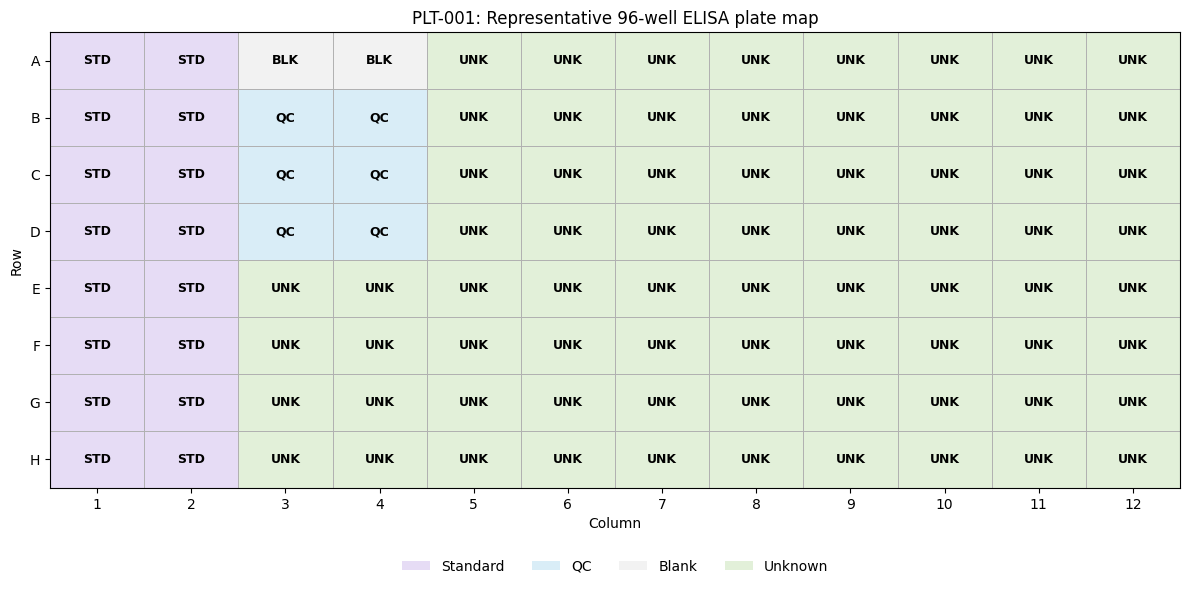

In [265]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

plate_id = "PLT-001"

plate_map_data = (
    df[df["Plate_ID"] == plate_id]
    .pivot(index="Row", columns="Column", values="Sample_Type")
    .reindex(index=list("ABCDEFGH"), columns=range(1, 13))
)

sample_type_codes = {
    "Standard": "STD",
    "QC": "QC",
    "Blank": "BLK",
    "Unknown": "UNK",
}

sample_type_numeric = {
    "Standard": 0,
    "QC": 1,
    "Blank": 2,
    "Unknown": 3,
}

# Convert sample types to numeric values for plotting.
# Using column-wise map avoids pandas replace downcasting warnings.
numeric_map = plate_map_data.apply(
    lambda column: column.map(sample_type_numeric)
).astype(float)

plate_cmap = ListedColormap([
    "#E6DCF5",  # Standard: light lavender
    "#D9EDF7",  # QC: light blue
    "#F2F2F2",  # Blank: light gray
    "#E2F0D9",  # Unknown: light green
])

fig, ax = plt.subplots(figsize=(12, 6))

ax.imshow(
    numeric_map,
    aspect="auto",
    cmap=plate_cmap,
    vmin=0,
    vmax=3
)

# Add abbreviated well-type labels.
for row_idx, row_name in enumerate(plate_map_data.index):
    for col_idx, col_name in enumerate(plate_map_data.columns):
        sample_type = plate_map_data.loc[row_name, col_name]

        if pd.notna(sample_type):
            ax.text(
                col_idx,
                row_idx,
                sample_type_codes[sample_type],
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold"
            )

# Label plate rows and columns.
ax.set_xticks(range(12))
ax.set_xticklabels(range(1, 13))
ax.set_yticks(range(8))
ax.set_yticklabels(list("ABCDEFGH"))

ax.set_xlabel("Column")
ax.set_ylabel("Row")
ax.set_title(f"{plate_id}: Representative 96-well ELISA plate map")

# Add well boundaries.
ax.set_xticks(np.arange(-0.5, 12, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 8, 1), minor=True)
ax.grid(which="minor", linewidth=0.7)
ax.tick_params(which="minor", bottom=False, left=False)

# Add a compact legend.
legend_items = [
    Patch(facecolor="#E6DCF5", label="Standard"),
    Patch(facecolor="#D9EDF7", label="QC"),
    Patch(facecolor="#F2F2F2", label="Blank"),
    Patch(facecolor="#E2F0D9", label="Unknown"),
]

ax.legend(
    handles=legend_items,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=4,
    frameon=False
)

plt.tight_layout()
plt.show()

## 4. Fit a 4-parameter logistic (4PL) standard curve to each plate

For concentration \(x\), the model used here is:

$$
y = \mathrm{Bottom} +
\frac{\mathrm{Top}-\mathrm{Bottom}}
{1+\left(\frac{\mathrm{EC50}}{x}\right)^{\mathrm{Hill}}}
$$

Each plate is analyzed independently using only the standard wells. Duplicate standard measurements are retained as separate observations rather than averaged before the 4PL fit.

In [266]:
def four_pl(x, bottom, top, ec50, hill):
    x = np.asarray(x, dtype=float)
    safe_x = np.clip(x, 1e-12, None)
    return bottom + (top - bottom) / (1.0 + (ec50 / safe_x) ** hill)


def inverse_four_pl(y, bottom, top, ec50, hill):
    """Back-calculate concentration from OD using a fitted increasing 4PL."""
    y = np.asarray(y, dtype=float)
    eps = 1e-9
    clipped_y = np.clip(y, bottom + eps, top - eps)
    ratio = (top - bottom) / (clipped_y - bottom) - 1.0
    return ec50 / np.power(ratio, 1.0 / hill)


fit_records = []

for plate_id, plate in df.groupby("Plate_ID"):
    standards = plate.loc[plate["Sample_Type"] == "Standard"].copy()
    x = standards["Expected_Concentration_pg_mL"].astype(float).to_numpy()
    y = standards["OD450"].astype(float).to_numpy()

    p0 = [max(0.0, y.min() * 0.8), y.max() * 1.05, 300.0, 1.2]
    bounds = ([0.0, 0.5, 1.0, 0.2], [1.0, 5.0, 5000.0, 5.0])

    popt, pcov = curve_fit(
        four_pl, x, y,
        p0=p0,
        bounds=bounds,
        maxfev=50000
    )
    predicted = four_pl(x, *popt)
    ss_res = np.sum((y - predicted) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot
    rmse_od = np.sqrt(np.mean((y - predicted) ** 2))

    back_calculated_standards = inverse_four_pl(y, *popt)
    standard_recovery_pct = (back_calculated_standards / x) * 100.0

    min_standard_recovery = np.min(standard_recovery_pct)
    max_standard_recovery = np.max(standard_recovery_pct)
    median_abs_standard_recovery_error = np.median(
        np.abs(standard_recovery_pct - 100.0)
    )

    fit_records.append({
        "Plate_ID": plate_id,
        "Bottom_OD": popt[0],
        "Top_OD": popt[1],
        "EC50_pg_mL": popt[2],
        "Hill_Slope": popt[3],
        "R2": r2,
        "RMSE_OD": rmse_od,
        "Min_Standard_Recovery_Pct": min_standard_recovery,
        "Max_Standard_Recovery_Pct": max_standard_recovery,
        "Median_Abs_Standard_Recovery_Error_Pct": median_abs_standard_recovery_error,
    })

fit_df = pd.DataFrame(fit_records).sort_values("Plate_ID").reset_index(drop=True)


fit_header_map = {
    "Plate_ID": "Plate\nID",
    "Bottom_OD": "Bottom\nOD",
    "Top_OD": "Top\nOD",
    "EC50_pg_mL": "EC50\n(pg/mL)",
    "Hill_Slope": "Hill\nSlope",
    "R2": "R²",
    "RMSE_OD": "RMSE\n(OD)",
    "Min_Standard_Recovery_Pct": "Min Standard\nRecovery (%)",
    "Max_Standard_Recovery_Pct": "Max Standard\nRecovery (%)",
    "Median_Abs_Standard_Recovery_Error_Pct":
        "Median Abs Recovery\nError (%)",
}

fit_formats = {
    "Bottom_OD": "{:.4f}",
    "Top_OD": "{:.4f}",
    "EC50_pg_mL": "{:.1f}",
    "Hill_Slope": "{:.3f}",
    "R2": "{:.5f}",
    "RMSE_OD": "{:.4f}",
    "Min_Standard_Recovery_Pct": "{:.1f}",
    "Max_Standard_Recovery_Pct": "{:.1f}",
    "Median_Abs_Standard_Recovery_Error_Pct": "{:.1f}",
}

display(
    format_portfolio_table(
        fit_df,
        header_map=fit_header_map,
        formats=fit_formats
    )
)

Plate ID,Bottom OD,Top OD,EC50 (pg/mL),Hill Slope,R²,RMSE (OD),Min Standard Recovery (%),Max Standard Recovery (%),Median Abs Recovery Error (%)
PLT-001,0.0334,2.5068,296.5,1.177,0.99993,0.0066,96.4,105.0,1.2
PLT-002,0.0550,2.3936,300.6,1.278,0.99987,0.0088,82.3,108.8,1.7
PLT-003,0.0333,2.5698,299.4,1.148,0.99969,0.0142,90.1,105.0,2.1
PLT-004,0.0392,2.5201,289.9,1.176,0.99972,0.0133,90.8,114.2,2.6
PLT-005,0.0579,2.5450,305.5,1.242,0.99972,0.0135,91.5,109.5,2.8
PLT-006,0.0519,2.4507,295.6,1.257,0.99969,0.0139,84.0,112.3,2.2
PLT-007,0.1669,2.5590,285.6,1.225,0.99981,0.0109,93.8,107.8,1.3
PLT-008,0.0554,2.3960,299.1,1.228,0.99984,0.0096,93.8,104.4,1.7
PLT-009,0.0595,2.3794,293.0,1.294,0.99976,0.0121,90.9,104.8,2.2
PLT-010,0.0407,2.4930,305.9,1.260,0.99983,0.0105,90.1,107.9,1.9


## 5. Representative 4PL standard curves

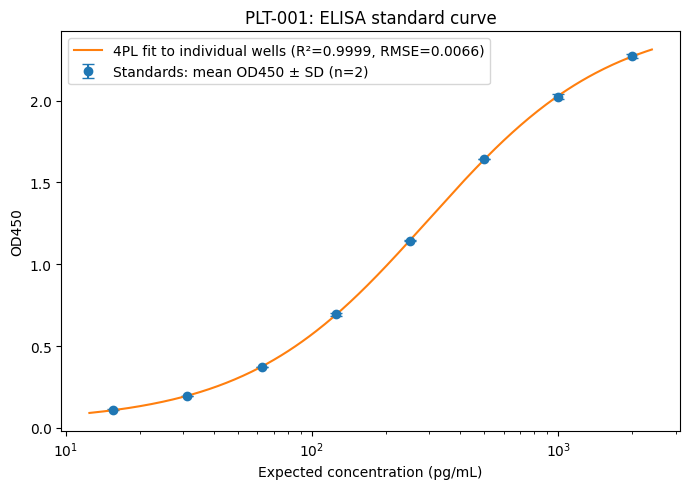

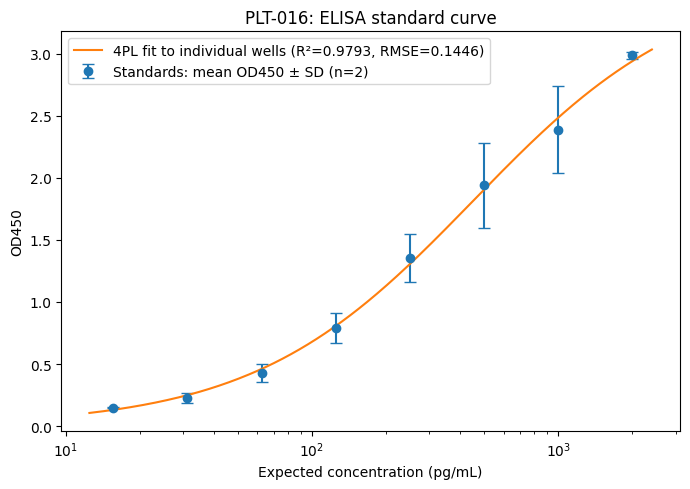

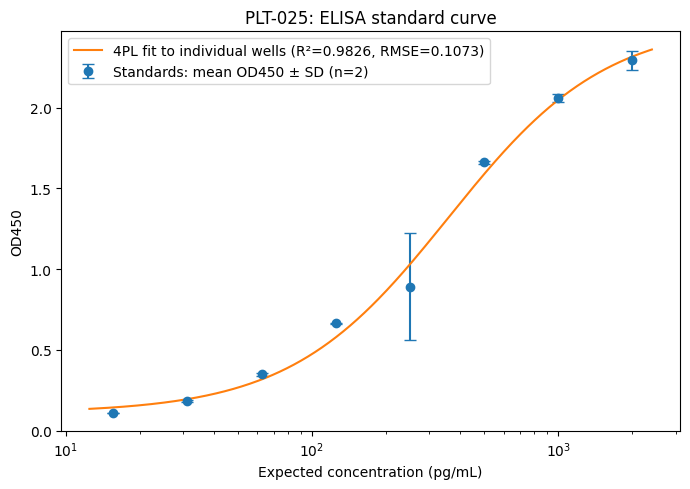

In [267]:
def plot_standard_curve(plate_id):
    plate = df[df["Plate_ID"] == plate_id]
    standards = plate[plate["Sample_Type"] == "Standard"].copy()
    fit = fit_df.loc[fit_df["Plate_ID"] == plate_id].iloc[0]

    # Summarize duplicate standard wells for visualization.
    # The 4PL model itself was fit using the individual replicate observations.
    standard_summary = (
        standards.groupby("Expected_Concentration_pg_mL", as_index=False)
        .agg(
            Mean_OD450=("OD450", "mean"),
            SD_OD450=("OD450", "std"),
            N=("OD450", "count"),
        )
        .sort_values("Expected_Concentration_pg_mL")
    )

    x_mean = standard_summary["Expected_Concentration_pg_mL"].to_numpy()
    y_mean = standard_summary["Mean_OD450"].to_numpy()
    y_sd = standard_summary["SD_OD450"].to_numpy()

    x_grid = np.logspace(
        np.log10(x_mean.min() * 0.8),
        np.log10(x_mean.max() * 1.2),
        400
    )

    plt.figure(figsize=(7, 5))

    plt.errorbar(
        x_mean,
        y_mean,
        yerr=y_sd,
        fmt="o",
        capsize=4,
        label="Standards: mean OD450 ± SD (n=2)"
    )

    plt.plot(
        x_grid,
        four_pl(
            x_grid,
            fit["Bottom_OD"],
            fit["Top_OD"],
            fit["EC50_pg_mL"],
            fit["Hill_Slope"]
        ),
        label=(
            f"4PL fit to individual wells "
            f"(R²={fit['R2']:.4f}, RMSE={fit['RMSE_OD']:.4f})"
        )
    )

    plt.xscale("log")
    plt.xlabel("Expected concentration (pg/mL)")
    plt.ylabel("OD450")
    plt.title(f"{plate_id}: ELISA standard curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_standard_curve("PLT-001")
plot_standard_curve("PLT-016")
plot_standard_curve("PLT-025")


PLT-001 is representative of a well-behaved curve. PLT-016 shows greater variability between duplicate wells associated with the planted edge effect, while PLT-025 shows a less consistent standard curve fit. Error bars represent mean OD450 ± SD for duplicate standard wells (n = 2).

## 6. Back-calculate concentrations from OD450

The fitted curve for each plate is used to estimate assay concentration. Dilution correction is then applied to unknown samples.

Blank wells are not assigned concentrations; they are evaluated directly using OD450.

In [268]:
results_parts = []

for plate_id, plate in df.groupby("Plate_ID"):
    plate = plate.copy()
    fit = fit_df.loc[fit_df["Plate_ID"] == plate_id].iloc[0]
    params = (fit["Bottom_OD"], fit["Top_OD"], fit["EC50_pg_mL"], fit["Hill_Slope"])

    nonblank = plate["Sample_Type"] != "Blank"
    plate["Analysis_Assay_Concentration_pg_mL"] = np.nan
    plate.loc[nonblank, "Analysis_Assay_Concentration_pg_mL"] = inverse_four_pl(
        plate.loc[nonblank, "OD450"].to_numpy(),
        *params
    )

    dilution = plate["Dilution_Factor"].fillna(1).astype(float)
    plate["Analysis_Final_Concentration_pg_mL"] = (
        plate["Analysis_Assay_Concentration_pg_mL"] * dilution
    )

    plate["Analysis_Result_Qualifier"] = "N/A"
    unknown = plate["Sample_Type"] == "Unknown"
    plate.loc[
        unknown & (plate["Analysis_Assay_Concentration_pg_mL"] < LLOQ),
        "Analysis_Result_Qualifier"
    ] = "<LLOQ"
    plate.loc[
        unknown & (plate["Analysis_Assay_Concentration_pg_mL"].between(LLOQ, ULOQ, inclusive="both")),
        "Analysis_Result_Qualifier"
    ] = "Quantifiable"
    plate.loc[
        unknown & (plate["Analysis_Assay_Concentration_pg_mL"] > ULOQ),
        "Analysis_Result_Qualifier"
    ] = ">ULOQ"

    results_parts.append(plate)

results = pd.concat(results_parts, ignore_index=True)

unknown_qualifiers = (
    results.loc[results["Sample_Type"] == "Unknown", "Analysis_Result_Qualifier"]
           .value_counts()
           .rename_axis("Qualifier")
           .to_frame("Well count")
)

unknown_qualifiers_display = (
    unknown_qualifiers
    .reset_index()
)

unknown_qualifiers_display["Qualifier"] = (
    unknown_qualifiers_display["Qualifier"]
    .replace({
        "<LLOQ": "Below LLOQ",
        ">ULOQ": "Above ULOQ",
    })
)

unknown_qualifier_header_map = {
    "Qualifier": "Result\nQualifier",
    "Well count": "Well\nCount",
}

display(
    format_portfolio_table(
        unknown_qualifiers_display,
        header_map=unknown_qualifier_header_map
    )
)

Result Qualifier,Well Count
Quantifiable,1208
Below LLOQ,542
Above ULOQ,50


## 7. Duplicate precision and QC recovery

In [269]:
group_cols = ["Plate_ID", "Sample_ID", "Sample_Type"]

sample_metrics = (
    results.groupby(group_cols, as_index=False)
           .agg(
               Mean_Calculated_Final_Concentration_pg_mL=("Analysis_Final_Concentration_pg_mL", "mean"),
               SD_Calculated_Final_Concentration_pg_mL=("Analysis_Final_Concentration_pg_mL", "std"),
               Expected_Concentration_pg_mL=("Expected_Concentration_pg_mL", "first"),
               N=("Replicate", "count"),
               All_Replicates_Quantifiable=(
    "Analysis_Result_Qualifier",
    lambda x: (x == "Quantifiable").all()
),
           )
)

sample_metrics["Replicate_CV_Pct"] = (
    sample_metrics["SD_Calculated_Final_Concentration_pg_mL"]
    / sample_metrics["Mean_Calculated_Final_Concentration_pg_mL"]
    * 100.0
)

sample_metrics["Recovery_Pct"] = (
    sample_metrics["Mean_Calculated_Final_Concentration_pg_mL"]
    / sample_metrics["Expected_Concentration_pg_mL"]
    * 100.0
)

qc_metrics = sample_metrics[sample_metrics["Sample_Type"] == "QC"].copy()

qc_header_map = {
    "Plate_ID": "Plate\nID",
    "Sample_ID": "Sample\nID",
    "Mean_Calculated_Final_Concentration_pg_mL":
        "Mean Calculated\nConc. (pg/mL)",
    "SD_Calculated_Final_Concentration_pg_mL":
        "SD Calculated\nConc. (pg/mL)",
    "Expected_Concentration_pg_mL":
        "Expected\nConc. (pg/mL)",
    "N": "N",
    "Replicate_CV_Pct":
        "Duplicate\nCV (%)",
    "Recovery_Pct":
        "Recovery\n(%)",
}


qc_formats = {
    "Mean_Calculated_Final_Concentration_pg_mL": "{:.1f}",
    "SD_Calculated_Final_Concentration_pg_mL": "{:.1f}",
    "Expected_Concentration_pg_mL": "{:.1f}",
    "Replicate_CV_Pct": "{:.2f}",
    "Recovery_Pct": "{:.1f}",
}

qc_display_cols = [
    "Plate_ID",
    "Sample_ID",
    "Mean_Calculated_Final_Concentration_pg_mL",
    "SD_Calculated_Final_Concentration_pg_mL",
    "Expected_Concentration_pg_mL",
    "N",
    "Replicate_CV_Pct",
    "Recovery_Pct",
]
display(
    format_portfolio_table(
        qc_metrics[qc_display_cols].head(12),
        header_map=qc_header_map,
        formats=qc_formats
    )
)

Plate ID,Sample ID,Mean Calculated Conc. (pg/mL),SD Calculated Conc. (pg/mL),Expected Conc. (pg/mL),N,Duplicate CV (%),Recovery (%)
PLT-001,QC_High,1218.8,18.9,1200.0,2,1.55,101.6
PLT-001,QC_Low,50.2,0.8,50.0,2,1.63,100.4
PLT-001,QC_Mid,299.0,6.0,300.0,2,2.00,99.7
PLT-002,QC_High,1194.3,76.4,1200.0,2,6.40,99.5
PLT-002,QC_Low,50.0,0.3,50.0,2,0.62,100.1
PLT-002,QC_Mid,298.9,14.8,300.0,2,4.95,99.6
PLT-003,QC_High,1258.1,127.9,1200.0,2,10.17,104.8
PLT-003,QC_Low,49.2,0.6,50.0,2,1.21,98.4
PLT-003,QC_Mid,302.6,5.2,300.0,2,1.73,100.9
PLT-004,QC_High,1150.1,62.2,1200.0,2,5.41,95.8


## 8. QC recovery across plates

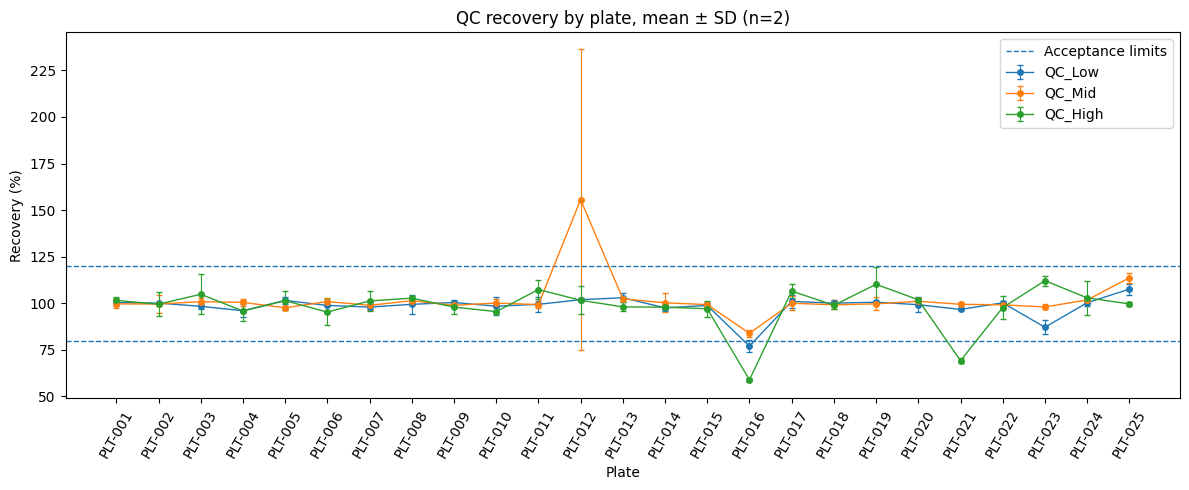

In [270]:
# Calculate QC recovery and corresponding SD for duplicate wells.
qc_plot = qc_metrics.copy()

qc_plot["Recovery_SD_Pct"] = (
    qc_plot["SD_Calculated_Final_Concentration_pg_mL"]
    / qc_plot["Expected_Concentration_pg_mL"]
    * 100
)

qc_recovery_wide = (
    qc_plot.pivot(
        index="Plate_ID",
        columns="Sample_ID",
        values="Recovery_Pct"
    )
    .reindex(fit_df["Plate_ID"])
)

qc_recovery_sd_wide = (
    qc_plot.pivot(
        index="Plate_ID",
        columns="Sample_ID",
        values="Recovery_SD_Pct"
    )
    .reindex(fit_df["Plate_ID"])
)

plt.figure(figsize=(12, 5))

for qc_name in ["QC_Low", "QC_Mid", "QC_High"]:
    plt.errorbar(
        qc_recovery_wide.index,
        qc_recovery_wide[qc_name],
        yerr=qc_recovery_sd_wide[qc_name],
        fmt="-o",
        capsize=2,
        markersize=4,
        linewidth=1,
        elinewidth=0.8,
        label=qc_name
    )

plt.axhline(
    80,
    linestyle="--",
    linewidth=1,
    label="Acceptance limits"
)
plt.axhline(
    120,
    linestyle="--",
    linewidth=1
)

plt.xticks(rotation=60)
plt.ylabel("Recovery (%)")
plt.xlabel("Plate")
plt.title("QC recovery by plate, mean ± SD (n=2)")
plt.legend()
plt.tight_layout()
plt.show()

Error bars represent ± SD for duplicate QC wells (n = 2). The illustrative 80% to 120% acceptance limits apply to mean QC recovery; duplicate precision is evaluated separately using QC CV.

## 9. Plate-level QC metrics

The primary pass/fail decision is based on blank background, standard curve fit, QC duplicate precision, and QC recovery.

In [271]:
plate_qc_records = []

for plate_id, plate in results.groupby("Plate_ID"):
    fit = fit_df.loc[fit_df["Plate_ID"] == plate_id].iloc[0]
    plate_qc = qc_metrics[qc_metrics["Plate_ID"] == plate_id]

    blank_mean = plate.loc[plate["Sample_Type"] == "Blank", "OD450"].mean()
    max_qc_cv = plate_qc["Replicate_CV_Pct"].max()
    min_qc_recovery = plate_qc["Recovery_Pct"].min()
    max_qc_recovery = plate_qc["Recovery_Pct"].max()

    unknown_metrics = sample_metrics[
        (sample_metrics["Plate_ID"] == plate_id) &
        (sample_metrics["Sample_Type"] == "Unknown") &
        (sample_metrics["All_Replicates_Quantifiable"])
    ]
    unknown_review_count = int((unknown_metrics["Replicate_CV_Pct"] > 20).sum())

    plate_qc_records.append({
        "Plate_ID": plate_id,
        "Mean_Blank_OD": blank_mean,
        "R2": fit["R2"],
        "Max_QC_CV_Pct": max_qc_cv,
        "Min_QC_Recovery_Pct": min_qc_recovery,
        "Max_QC_Recovery_Pct": max_qc_recovery,
        "Unknown_Samples_CV_Review_Count": unknown_review_count,
    })

plate_qc = pd.DataFrame(plate_qc_records).sort_values("Plate_ID").reset_index(drop=True)
plate_qc_header_map = {
    "Plate_ID": "Plate\nID",
    "Mean_Blank_OD": "Mean Blank\nOD",
    "R2": "R²",
    "Max_QC_CV_Pct": "Max QC\nCV (%)",
    "Min_QC_Recovery_Pct": "Min QC\nRecovery (%)",
    "Max_QC_Recovery_Pct": "Max QC\nRecovery (%)",
    "Unknown_Samples_CV_Review_Count": "Unknown Sample\nCV Reviews",
}

plate_qc_formats = {
    "Mean_Blank_OD": "{:.4f}",
    "R2": "{:.5f}",
    "Max_QC_CV_Pct": "{:.1f}",
    "Min_QC_Recovery_Pct": "{:.1f}",
    "Max_QC_Recovery_Pct": "{:.1f}",
    "Unknown_Samples_CV_Review_Count": "{:.0f}",
}

display(
    format_portfolio_table(
        plate_qc.head(),
        header_map=plate_qc_header_map,
        formats=plate_qc_formats
    )
)

Plate ID,Mean Blank OD,R²,Max QC CV (%),Min QC Recovery (%),Max QC Recovery (%),Unknown Sample CV Reviews
PLT-001,0.0432,0.99993,2.0,99.7,101.6,0
PLT-002,0.0512,0.99987,6.4,99.5,100.1,0
PLT-003,0.0423,0.99969,10.2,98.4,104.8,0
PLT-004,0.0490,0.99972,5.4,95.8,100.5,0
PLT-005,0.0520,0.99972,5.1,97.6,101.6,0


## 10. Check for a possible edge effect

In this synthetic plate layout, the two standard replicates are in adjacent columns: replicate 1 is in **column 1 at the plate edge**, and replicate 2 is in **column 2, one position inward**. This provides a direct positional comparison at each standard concentration.

For each plate, we calculate the percent OD difference between the paired standard wells. A large, consistent positive difference suggests higher signal at the outer edge rather than ordinary duplicate variability.

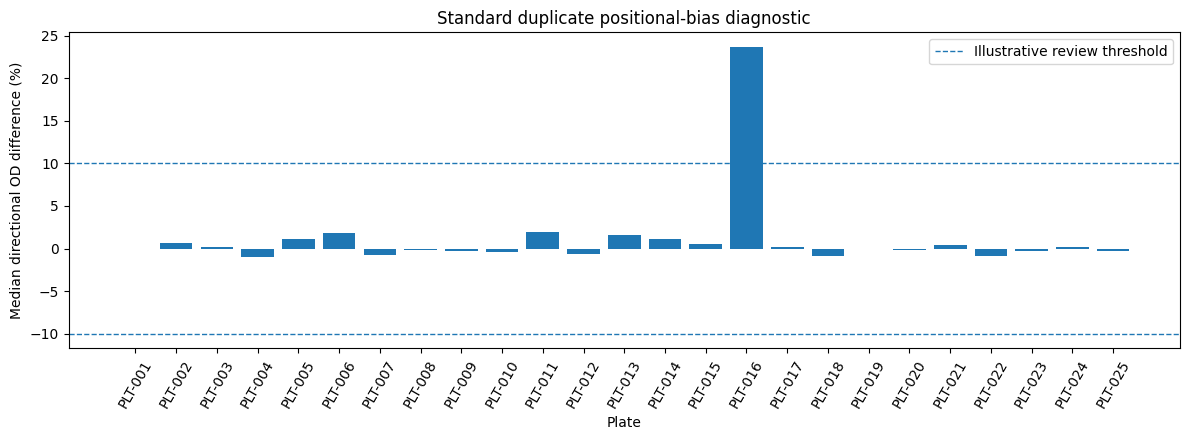

Plate ID,Median Edge vs Interior OD Diff (%),Max Absolute Standard Duplicate OD Diff (%)
PLT-016,23.7,29.1
PLT-011,2.0,5.9
PLT-006,1.8,7.5
PLT-013,1.6,6.2
PLT-014,1.1,4.2


In [255]:
edge_records = []

for plate_id, plate in df.groupby("Plate_ID"):
    standards = plate[plate["Sample_Type"] == "Standard"].copy()
    paired = standards.pivot(
        index="Expected_Concentration_pg_mL",
        columns="Replicate",
        values="OD450"
    )

    pct_difference = (paired[1] / paired[2] - 1.0) * 100.0

    edge_records.append({
        "Plate_ID": plate_id,
        "Median_Standard_Edge_vs_Interior_OD_Diff_Pct": pct_difference.median(),
        "Max_Absolute_Standard_Duplicate_OD_Diff_Pct": pct_difference.abs().max(),
    })

edge_diag = pd.DataFrame(edge_records).sort_values("Plate_ID").reset_index(drop=True)

plt.figure(figsize=(12, 4.5))
plt.bar(
    edge_diag["Plate_ID"],
    edge_diag["Median_Standard_Edge_vs_Interior_OD_Diff_Pct"]
)
plt.axhline(10, linestyle="--", linewidth=1, label="Illustrative review threshold")
plt.axhline(-10, linestyle="--", linewidth=1)
plt.xticks(rotation=60)
plt.ylabel("Median directional OD difference (%)")
plt.xlabel("Plate")
plt.title("Standard duplicate positional-bias diagnostic")
plt.legend()
plt.tight_layout()
plt.show()

edge_header_map = {
    "Plate_ID": "Plate\nID",
    "Median_Standard_Edge_vs_Interior_OD_Diff_Pct":
        "Median Edge vs\nInterior OD Diff (%)",
    "Max_Absolute_Standard_Duplicate_OD_Diff_Pct":
        "Max Absolute Standard\nDuplicate OD Diff (%)",
}

edge_formats = {
    "Median_Standard_Edge_vs_Interior_OD_Diff_Pct": "{:.1f}",
    "Max_Absolute_Standard_Duplicate_OD_Diff_Pct": "{:.1f}",
}

edge_top5 = (
    edge_diag
    .sort_values(
        "Median_Standard_Edge_vs_Interior_OD_Diff_Pct",
        ascending=False
    )
    .head(5)
)

display(
    format_portfolio_table(
        edge_top5,
        header_map=edge_header_map,
        formats=edge_formats
    )
)

## 11. Read order drift diagnostic

To keep read order effects separate from differences in unknown sample concentration, this diagnostic uses only wells with known expected concentrations: **standards, QCs, and blanks.**

For each known well, we calculate:

**OD residual = observed OD - OD expected from the fitted 4PL**

We then compare those residuals with read order. A consistent upward or downward trend suggests signal drift during plate reading.

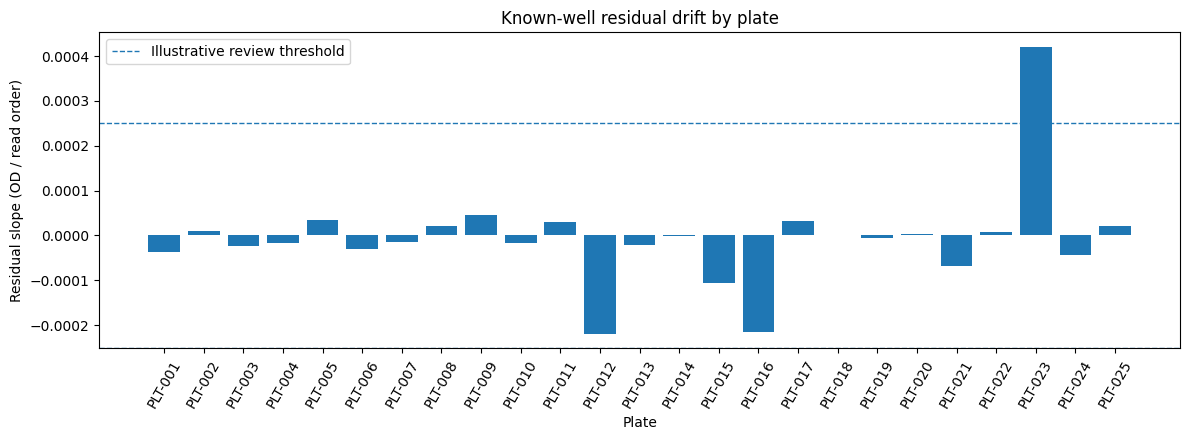

Plate ID,Residual Slope (OD/read)
PLT-023,0.0004209
PLT-012,-0.0002187
PLT-016,-0.0002153
PLT-015,-0.0001050
PLT-021,-0.0000692


In [256]:
drift_records = []

for plate_id, plate in df.groupby("Plate_ID"):
    fit = fit_df.loc[fit_df["Plate_ID"] == plate_id].iloc[0]
    params = (fit["Bottom_OD"], fit["Top_OD"], fit["EC50_pg_mL"], fit["Hill_Slope"])

    known = plate[plate["Sample_Type"].isin(["Standard", "QC", "Blank"])].copy()
    known["Expected_For_Model"] = known["Expected_Concentration_pg_mL"].fillna(0.0)
    known["Expected_OD"] = four_pl(known["Expected_For_Model"].to_numpy(), *params)
    known["OD_Residual"] = known["OD450"] - known["Expected_OD"]

    slope, intercept = np.polyfit(
        known["Read_Order"].astype(float),
        known["OD_Residual"].astype(float),
        1
    )

    drift_records.append({
        "Plate_ID": plate_id,
        "Known_Well_Residual_Slope_OD_per_Read": slope,
    })

drift_diag = pd.DataFrame(drift_records).sort_values("Plate_ID").reset_index(drop=True)

plt.figure(figsize=(12, 4.5))
plt.bar(
    drift_diag["Plate_ID"],
    drift_diag["Known_Well_Residual_Slope_OD_per_Read"]
)
plt.axhline(0.00025, linestyle="--", linewidth=1, label="Illustrative review threshold")
plt.axhline(-0.00025, linestyle="--", linewidth=1)
plt.xticks(rotation=60)
plt.ylabel("Residual slope (OD / read order)")
plt.xlabel("Plate")
plt.title("Known-well residual drift by plate")
plt.legend()
plt.tight_layout()
plt.show()

drift_header_map = {
    "Plate_ID": "Plate\nID",
    "Known_Well_Residual_Slope_OD_per_Read":
        "Residual Slope\n(OD/read)",
}

drift_formats = {
    "Known_Well_Residual_Slope_OD_per_Read": "{:.7f}",
}

drift_top5 = (
    drift_diag
    .reindex(
        drift_diag["Known_Well_Residual_Slope_OD_per_Read"]
        .abs()
        .sort_values(ascending=False)
        .index
    )
    .head(5)
)

display(
    format_portfolio_table(
        drift_top5,
        header_map=drift_header_map,
        formats=drift_formats
    )
)

In [257]:
plate_summary = (
    plate_qc
    .merge(edge_diag, on="Plate_ID", how="left")
    .merge(drift_diag, on="Plate_ID", how="left")
)

def classify_plate(row):
    primary_reasons = []

    if row["Mean_Blank_OD"] > 0.150:
        primary_reasons.append("High blank")
    if row["R2"] < 0.990:
        primary_reasons.append("Curve fit")
    if row["Max_QC_CV_Pct"] > 20:
        primary_reasons.append("QC CV")
    if row["Min_QC_Recovery_Pct"] < 80 or row["Max_QC_Recovery_Pct"] > 120:
        primary_reasons.append("QC recovery")

    review_reasons = []
    if abs(row["Known_Well_Residual_Slope_OD_per_Read"]) > 0.00025:
        review_reasons.append("Read-order drift")

    explanatory = []
    if abs(row["Median_Standard_Edge_vs_Interior_OD_Diff_Pct"]) > 10:
        explanatory.append("Position/edge bias")
    if row["Max_Absolute_Standard_Duplicate_OD_Diff_Pct"] > 20:
        explanatory.append("Large standard duplicate discrepancy")

    if primary_reasons:
        status = "Fail"
    elif review_reasons:
        status = "Review"
    else:
        status = "Pass"

    return pd.Series({
        "Plate_Status": status,
        "Primary_QC_Findings": "; ".join(primary_reasons) if primary_reasons else "None",
        "Review_Findings": "; ".join(review_reasons) if review_reasons else "None",
        "Explanatory_Diagnostics": "; ".join(explanatory) if explanatory else "None",
    })

classification = plate_summary.apply(classify_plate, axis=1)
plate_summary = pd.concat([plate_summary, classification], axis=1)

summary_display_cols = [
    "Plate_ID", "Mean_Blank_OD", "R2", "Max_QC_CV_Pct",
    "Min_QC_Recovery_Pct", "Max_QC_Recovery_Pct",
    "Median_Standard_Edge_vs_Interior_OD_Diff_Pct",
    "Known_Well_Residual_Slope_OD_per_Read",
    "Plate_Status", "Primary_QC_Findings", "Review_Findings",
    "Explanatory_Diagnostics",
]

header_map = {
    "Plate_ID": "Plate\nID",
    "Mean_Blank_OD": "Mean Blank\nOD",
    "R2": "R²",
    "Max_QC_CV_Pct": "Max QC\nCV (%)",
    "Min_QC_Recovery_Pct": "Min QC\nRecovery (%)",
    "Max_QC_Recovery_Pct": "Max QC\nRecovery (%)",
    "Median_Standard_Edge_vs_Interior_OD_Diff_Pct":
        "Median Edge vs\nInterior OD Diff (%)",
    "Known_Well_Residual_Slope_OD_per_Read":
        "Residual Slope\n(OD/read)",
    "Plate_Status": "Plate\nStatus",
    "Primary_QC_Findings": "Primary QC\nFindings",
    "Review_Findings": "Review\nFindings",
    "Explanatory_Diagnostics": "Explanatory\nDiagnostics",
}

summary_formats = {
    "Mean_Blank_OD": "{:.4f}",
    "R2": "{:.5f}",
    "Max_QC_CV_Pct": "{:.1f}",
    "Min_QC_Recovery_Pct": "{:.1f}",
    "Max_QC_Recovery_Pct": "{:.1f}",
    "Median_Standard_Edge_vs_Interior_OD_Diff_Pct": "{:.1f}",
    "Known_Well_Residual_Slope_OD_per_Read": "{:.7f}",
}

display(
    format_portfolio_table(
        plate_summary[summary_display_cols],
        header_map=header_map,
        formats=summary_formats
    )
)

print("\nStatus counts:")

status_counts = (
    plate_summary["Plate_Status"]
    .value_counts()
    .rename_axis("Plate_Status")
    .reset_index(name="Plates")
)

status_header_map = {
    "Plate_Status": "Plate\nStatus",
    "Plates": "Number of\nPlates",
}

display(
    format_portfolio_table(
        status_counts,
        header_map=status_header_map
    )
)

Plate ID,Mean Blank OD,R²,Max QC CV (%),Min QC Recovery (%),Max QC Recovery (%),Median Edge vs Interior OD Diff (%),Residual Slope (OD/read),Plate Status,Primary QC Findings,Review Findings,Explanatory Diagnostics
PLT-001,0.0432,0.99993,2.0,99.7,101.6,-0.0,-0.0000368,Pass,None,None,None
PLT-002,0.0512,0.99987,6.4,99.5,100.1,0.6,0.0000092,Pass,None,None,None
PLT-003,0.0423,0.99969,10.2,98.4,104.8,0.2,-0.0000242,Pass,None,None,None
PLT-004,0.0490,0.99972,5.4,95.8,100.5,-1.0,-0.0000172,Pass,None,None,None
PLT-005,0.0520,0.99972,5.1,97.6,101.6,1.1,0.0000337,Pass,None,None,None
PLT-006,0.0543,0.99969,7.5,95.3,100.9,1.8,-0.0000300,Pass,None,None,None
PLT-007,0.1761,0.99981,5.1,98.0,101.3,-0.8,-0.0000138,Fail,High blank,None,None
PLT-008,0.0497,0.99984,5.1,99.4,102.8,-0.1,0.0000211,Pass,None,None,None
PLT-009,0.0479,0.99976,3.5,98.0,100.4,-0.3,0.0000467,Pass,None,None,None
PLT-010,0.0458,0.99983,5.1,95.5,100.1,-0.4,-0.0000177,Pass,None,None,None



Status counts:


Plate Status,Number of Plates
Pass,19
Fail,5
Review,1


## 12. Combine primary QC and diagnostic findings

- **Fail** = at least one primary QC criterion fails.
- **Review** = primary QC criteria pass, but the read order drift diagnostic exceeds its review threshold.
- **Pass** = primary QC criteria pass and no drift review is triggered.

The edge effect and standard duplicate diagnostics are retained as supporting information to help explain unusual plate behavior.

In [258]:
planted_anomalies = {
    "PLT-007": "High background",
    "PLT-012": "Replicate imprecision",
    "PLT-016": "Edge effect",
    "PLT-021": "Poor high-QC recovery",
    "PLT-023": "Read-order / instrument drift",
    "PLT-025": "Standard-curve outlier",
}

truth = pd.DataFrame(
    [{"Plate_ID": plate, "Planted_Anomaly": issue} for plate, issue in planted_anomalies.items()]
)

validation = truth.merge(
    plate_summary[
        [
            "Plate_ID", "Plate_Status", "Primary_QC_Findings",
            "Review_Findings", "Explanatory_Diagnostics"
        ]
    ],
    on="Plate_ID",
    how="left"
)

validation["Detected"] = validation["Plate_Status"].isin(["Fail", "Review"])

validation_header_map = {
    "Plate_ID": "Plate\nID",
    "Planted_Anomaly": "Planted\nAnomaly",
    "Plate_Status": "Plate\nStatus",
    "Primary_QC_Findings": "Primary QC\nFindings",
    "Review_Findings": "Review\nFindings",
    "Explanatory_Diagnostics": "Explanatory\nDiagnostics",
    "Detected": "Anomaly\nDetected",
}

display(
    format_portfolio_table(
        validation,
        header_map=validation_header_map
    )
)

anomaly_detection_rate = validation["Detected"].mean() * 100
routine = plate_summary[~plate_summary["Plate_ID"].isin(planted_anomalies)]
routine_pass_rate = (routine["Plate_Status"] == "Pass").mean() * 100

print(f"Planted anomaly plates detected: {validation['Detected'].sum()}/{len(validation)} ({anomaly_detection_rate:.0f}%)")
print(f"Routine plates classified Pass: {(routine['Plate_Status']=='Pass').sum()}/{len(routine)} ({routine_pass_rate:.0f}%)")


Plate ID,Planted Anomaly,Plate Status,Primary QC Findings,Review Findings,Explanatory Diagnostics,Anomaly Detected
PLT-007,High background,Fail,High blank,None,None,True
PLT-012,Replicate imprecision,Fail,QC CV; QC recovery,None,None,True
PLT-016,Edge effect,Fail,Curve fit; QC recovery,None,Position/edge bias; Large standard duplicate discrepancy,True
PLT-021,Poor high-QC recovery,Fail,QC recovery,None,None,True
PLT-023,Read-order / instrument drift,Review,None,Read-order drift,None,True
PLT-025,Standard-curve outlier,Fail,Curve fit,None,Large standard duplicate discrepancy,True


Planted anomaly plates detected: 6/6 (100%)
Routine plates classified Pass: 19/19 (100%)


## 13. Plate status overview

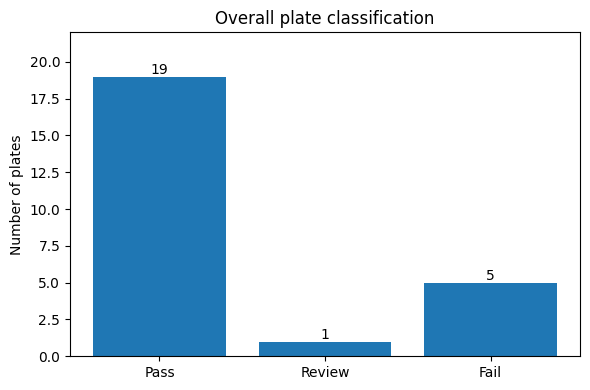

In [259]:
status_counts = (
    plate_summary["Plate_Status"]
    .value_counts()
    .reindex(["Pass", "Review", "Fail"], fill_value=0)
)

plt.figure(figsize=(6, 4))
plt.bar(status_counts.index, status_counts.values)
plt.ylabel("Number of plates")
plt.title("Overall plate classification")
for i, value in enumerate(status_counts.values):
    plt.text(i, value + 0.15, str(value), ha="center")
plt.ylim(0, max(status_counts.values) + 3)
plt.tight_layout()
plt.show()


## 14. Investigate the plates requiring attention

This condensed table provides a practical summary that a laboratory scientist or manager could use to prioritize review.

In [260]:
attention = plate_summary.loc[
    plate_summary["Plate_Status"] != "Pass",
    [
        "Plate_ID", "Plate_Status", "Primary_QC_Findings",
        "Review_Findings", "Explanatory_Diagnostics",
        "Mean_Blank_OD", "R2", "Max_QC_CV_Pct",
        "Min_QC_Recovery_Pct", "Max_QC_Recovery_Pct",
    ]
].copy()
attention_header_map = {
    "Plate_ID": "Plate\nID",
    "Plate_Status": "Plate\nStatus",
    "Primary_QC_Findings": "Primary QC\nFindings",
    "Review_Findings": "Review\nFindings",
    "Explanatory_Diagnostics": "Explanatory\nDiagnostics",
    "Mean_Blank_OD": "Mean Blank\nOD",
    "R2": "R²",
    "Max_QC_CV_Pct": "Max QC\nCV (%)",
    "Min_QC_Recovery_Pct": "Min QC\nRecovery (%)",
    "Max_QC_Recovery_Pct": "Max QC\nRecovery (%)",
}

attention_formats = {
    "Mean_Blank_OD": "{:.4f}",
    "R2": "{:.5f}",
    "Max_QC_CV_Pct": "{:.1f}",
    "Min_QC_Recovery_Pct": "{:.1f}",
    "Max_QC_Recovery_Pct": "{:.1f}",
}

display(
    format_portfolio_table(
        attention,
        header_map=attention_header_map,
        formats=attention_formats
    )
)

Plate ID,Plate Status,Primary QC Findings,Review Findings,Explanatory Diagnostics,Mean Blank OD,R²,Max QC CV (%),Min QC Recovery (%),Max QC Recovery (%)
PLT-007,Fail,High blank,None,None,0.1761,0.99981,5.1,98.0,101.3
PLT-012,Fail,QC CV; QC recovery,None,None,0.0490,0.99983,52.0,101.6,155.6
PLT-016,Fail,Curve fit; QC recovery,None,Position/edge bias; Large standard duplicate discrepancy,0.0647,0.97928,4.2,58.9,83.9
PLT-021,Fail,QC recovery,None,None,0.0541,0.99977,1.7,69.2,99.5
PLT-023,Review,None,Read-order drift,None,0.0481,0.99955,4.2,87.1,112.1
PLT-025,Fail,Curve fit,None,Large standard duplicate discrepancy,0.0472,0.98259,2.7,99.7,113.7


## 15. Synthetic design comparison: consulted only after analysis

At this point, the analytical workflow is complete. We can now compare the results with the known synthetic design.

Six plates were deliberately generated with specific problems. This final comparison checks whether the workflow flagged those plates without using the synthetic ground truth fields for concentration, CV, recovery, or QC status.

## Conclusions

This synthetic case study documents a complete scientific data analysis workflow that:

- Fits independent nonlinear 4PL curves for multiple assay plates.
- Back-calculates concentrations directly from OD450.
- Applies dilution correction.
- Calculates duplicate precision and QC recovery in Python.
- Automates plate-level QC decisions.
- Detects high background, duplicate imprecision, poor recovery, standard curve fit problems, positional bias, and read order drift.
- Separates **primary acceptance criteria** from **supporting diagnostic findings**.
- Compares the detected anomalies with the known synthetic design only after the analysis is complete.

## Portfolio relevance

The workflow combines assay science with Python to support reproducible laboratory data analysis, transparent QC review, and consistent decision making across multiple plates.

**Methods used:** ELISA · 4PL nonlinear regression · assay QC · precision · recovery · dilution correction · anomaly detection · data visualization · Python · scientific decision support